In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import math  
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.special import erfc
from sklearn.neighbors import KNeighborsClassifier

In [2]:
def mod(V):
    ip = np.zeros((len(V),1),dtype=complex)
    inc = 0
    for v in V:
        if(v==0):
            ip[inc] = (-3-3j)
        elif(v==1):
            ip[inc] = (-3-1j)
        elif(v==2):
            ip[inc] = (-3+3j)
        elif(v==3):
            ip[inc] = (-3+1j)
        elif(v==4):
            ip[inc] = (-1-3j)
        elif(v==5):
            ip[inc] = (-1-1j)
        elif(v==6):
            ip[inc] = (-1+3j)
        elif(v==7):
            ip[inc] = (-1+1j)
        elif(v==8):
            ip[inc] = (3-3j)
        elif(v==9):
            ip[inc] = (3-1j)
        elif(v==10):
            ip[inc] = (3+3j)
        elif(v==11):
            ip[inc] = (3+1j)
        elif(v==12):
            ip[inc] = (1-3j)
        elif(v==13):
            ip[inc] = ( 1-1j)
        elif(v==14):
            ip[inc] = (1+3j)
        else:
            ip[inc] = (1+1j)
            
        inc += 1
    # Normalization of energy to 1.
    s = (1/np.sqrt(10))*ip;
    return s



def demod(c):
    c_seq = mod(np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]))
    c_seq = c_seq[:,0]
    e = []
    for i in range(0,len(c_seq)):
        e.append(np.abs(c_seq[i] - c)**2)
    return e.index(np.min(e))

In [3]:
# Number of 16QAM symbols to be transmitted.
N = 100000
M = 16
k = np.sqrt(3/(2*(M-1)))

In [4]:
# Create Es/N0 vector.
EsN0dB = np.arange(-2,22,2)

ser_simu = np.zeros(len(EsN0dB))
ser_theo = np.zeros(len(EsN0dB))

ber_theo = ber_simu = np.zeros(len(EsN0dB))


    
for idx in range(0,len(EsN0dB)):    

    
    EsN0Lin = 10.0**(-(EsN0dB[idx]/10.0))
    
    # Generate N binary symbols.
    V = np.random.randint(0,M,(N,1))
    
    
    # Modulate binary stream into 16QAM symbols.
    s = mod(V)
    
    
    # Generate noise vector. 
    noise = np.sqrt(1.0/2.0)*(np.random.randn(N, 1) + 1j*np.random.randn(N, 1))
   

    # Pass symbols through AWGN channel.
    y = s + np.sqrt(EsN0Lin)*noise
    
    Y = np.c_[y.real, y.imag]
    
    # Fit models for real and imaginary parts.
    km = KNeighborsClassifier(n_neighbors=M)

    km.fit(Y,V[:,0])
    
    # Prediction.
    detected = km.predict(Y)
    
    # Simulated 16QAM BER.
    error = 0
    for i in range(0, len(V)):

        if((V[i,0] != detected[i])==True): 
            error = error + 1
    
    ser_simu[idx] = 1.0 * error / len(V)
    
    
    EsN0 = 10.0**(EsN0dB[idx]/10.0)
    ser_theo[idx] = 2*(1 - (1/np.sqrt(M)) )*erfc( k*np.sqrt(EsN0)   ) - ( 1 - (2/np.sqrt(M)) + (1/M) )*(erfc(  k*np.sqrt(EsN0) ) )**2.0

In [5]:
# Print Es/N0 versus SER values.
for i in range(0,len(ser_simu)): print('Es/N0:%d \t- SER: %e' % (EsN0dB[i], ser_simu[i]))

Es/N0:-2 	- SER: 7.151000e-01
Es/N0:0 	- SER: 6.732700e-01
Es/N0:2 	- SER: 6.194800e-01
Es/N0:4 	- SER: 5.470200e-01
Es/N0:6 	- SER: 4.547800e-01
Es/N0:8 	- SER: 3.376800e-01
Es/N0:10 	- SER: 2.143300e-01
Es/N0:12 	- SER: 1.053200e-01
Es/N0:14 	- SER: 3.654000e-02
Es/N0:16 	- SER: 6.930000e-03
Es/N0:18 	- SER: 5.900000e-04
Es/N0:20 	- SER: 1.000000e-05


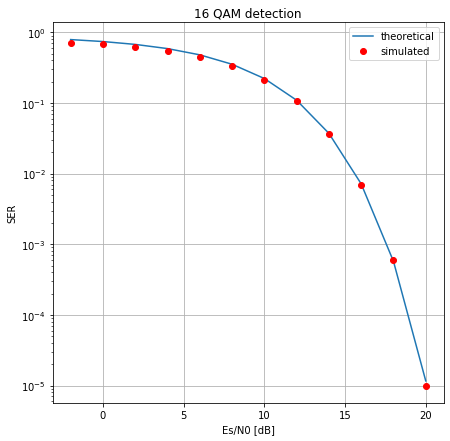

In [6]:
# Plot Es/N0 versus BER values.
fig = plt.figure(figsize=(7,7))
plt.plot(EsN0dB, ser_theo, label='theoretical')
plt.plot(EsN0dB, ser_simu, 'ro', label='simulated')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Es/N0 [dB]')
plt.ylabel('SER')
plt.grid(True)
plt.title('16 QAM detection')
plt.legend()
plt.show()

**4c) Resposta:** Sim. É possivel observar que a curva simulada se aproxíma perfeitamente a da curva teórica SER.